In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing   
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [24]:
data = fetch_california_housing(as_frame=True)
print(data.DESCR)

.. _california_housing_dataset:

California Housing dataset
--------------------------

**Data Set Characteristics:**

:Number of Instances: 20640

:Number of Attributes: 8 numeric, predictive attributes and the target

:Attribute Information:
    - MedInc        median income in block group
    - HouseAge      median house age in block group
    - AveRooms      average number of rooms per household
    - AveBedrms     average number of bedrooms per household
    - Population    block group population
    - AveOccup      average number of household members
    - Latitude      block group latitude
    - Longitude     block group longitude

:Missing Attribute Values: None

This dataset was obtained from the StatLib repository.
https://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html

The target variable is the median house value for California districts,
expressed in hundreds of thousands of dollars ($100,000).

This dataset was derived from the 1990 U.S. census, using one row per ce

In [25]:
print(data.target.name)


MedHouseVal


In [26]:

df = pd.concat([data.data, data.target.rename("HousePrice")], axis=1)
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,HousePrice
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [27]:
# Remove all rows where the HousePrice is exactly equal or greater than  5.0
df_filtered = df[df["HousePrice"] < 5.0]

# Optional: Print to see how many rows were removed
print(f"Original dataset rows: {len(df)}")
print(f"Filtered dataset rows: {len(df_filtered)}")
print(f"Removed rows: {len(df) - len(df_filtered)}")

# Separate Features and Target Variable 
# Make sure to use 'df_filtered' instead of 'df' here
X = df_filtered.drop("HousePrice", axis=1)
y = df_filtered["HousePrice"]

Original dataset rows: 20640
Filtered dataset rows: 19648
Removed rows: 992


In [28]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [29]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [30]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Decision Tree": DecisionTreeRegressor(max_depth=10)
}

In [31]:
from sklearn.metrics import root_mean_squared_error
results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)
    
    # Calculate Metrics
    rmse =root_mean_squared_error(y_test, predictions)
    r2 = r2_score(y_test, predictions)
    
    results[name] = {
        "RMSE": rmse,
        "R2 Score": r2
    }

# Convert results dictionary into a structured comparison table
results_df = pd.DataFrame(results).T
print(results_df)

                       RMSE  R2 Score
Linear Regression  0.642864  0.568935
Ridge Regression   0.642870  0.568927
Decision Tree      0.579413  0.649829


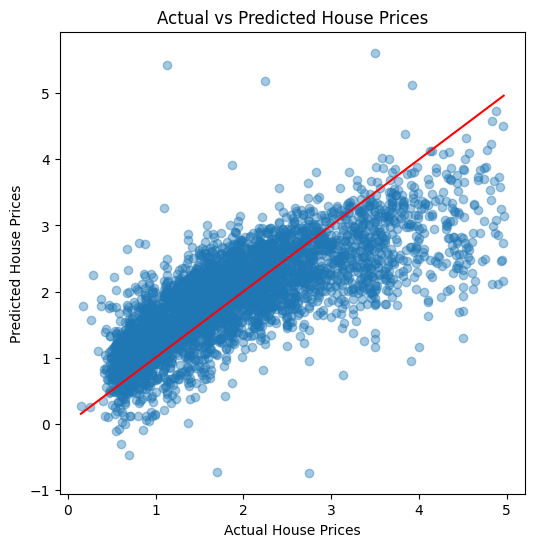

In [32]:
best_model = LinearRegression()
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

plt.figure(figsize=(6,6))
plt.scatter(y_test, y_pred, alpha=0.4)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="red")
plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [33]:
import joblib

# retrain my best-performing model
best_model = DecisionTreeRegressor(max_depth=10, random_state=42)
best_model.fit(X_train, y_train)

model_filename = "best_house_price_model.pkl"

joblib.dump(best_model, model_filename)

print(f" model saved as: {model_filename}")

 model saved as: best_house_price_model.pkl
